In [6]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.interference_models.pca import loo_pca, malinowski_ind, pca
from vebir.absorbance_estimators.ebs import EBS
from vebir.absorbance_estimators.veb import VEB, norm_cdf, norm_pdf, pinball_loss, als_loss, pb_map, als_map
from vebir.utils.metrics import compute_compound_cors, compute_method_cors
import pandas as pd 
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import cvxpy as cp

from scipy.linalg import svd

In [93]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "ebs"

with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)

with open(PREPROC_DIR / "raw_spectra_dict.pkl", "rb") as f:
    raw_spectra_dict = pickle.load(f)

with open(GT_DIR / "ref_dict.pkl", "rb") as file:
    ref_dict = pickle.load(file)
    
with open(PREPROC_DIR / "spectra_responses.pkl", "rb") as f:
    spectra_responses = pickle.load(f)

CO2 = ref_dict["CO2"]
H2O = np.array(pd.read_csv("../data/spectrabase/teflon/H2O_spectrum.csv"))

del ref_dict["CO2"]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

In [94]:
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "veb" / "pb"

### 12-Tricosanone

In [ ]:
comp = "12-Tricosanone"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

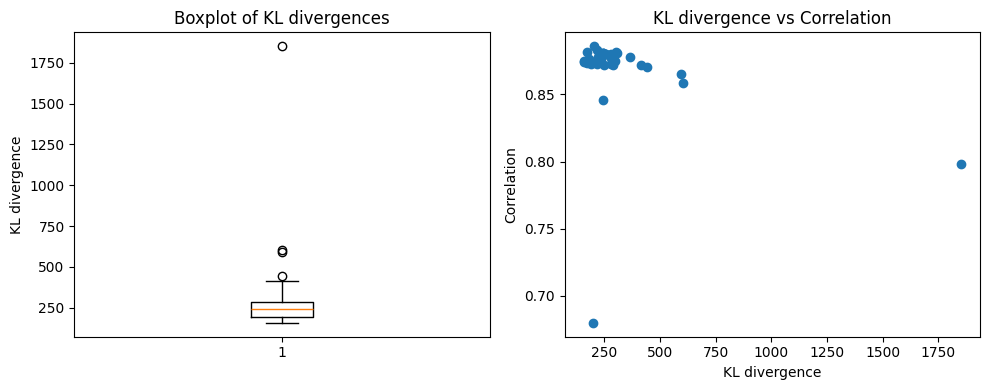

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

In [168]:
np.flip(np.argsort(KL))

array([ 1,  4,  5, 19,  7,  8, 38, 37, 11, 26, 10, 36, 27, 34, 31, 25,  2,
       33, 35, 29, 18, 28, 24, 13,  9, 17, 32, 30,  0, 23, 21, 14, 12, 22,
        3, 16, 20,  6, 15])

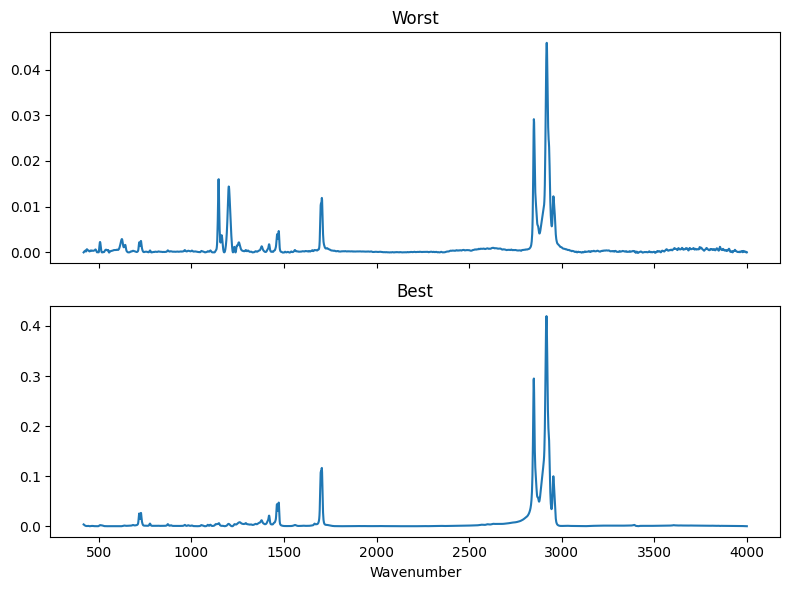

In [169]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[1]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[15]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

### SO4

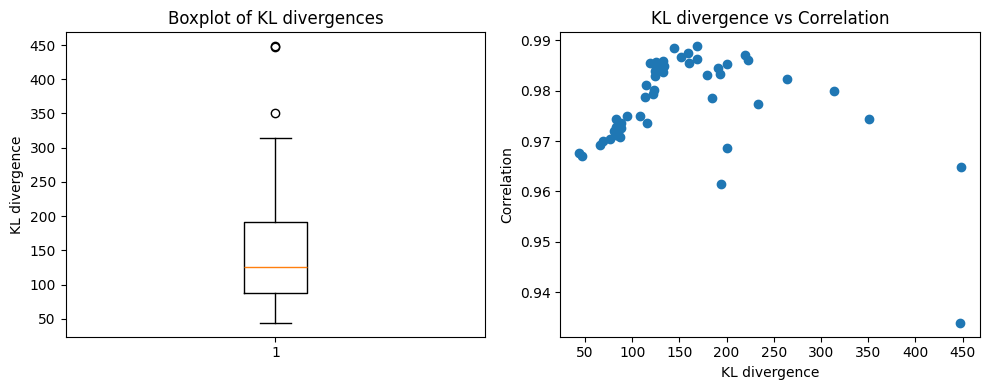

In [179]:
comp = "Ammonium sulfate"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

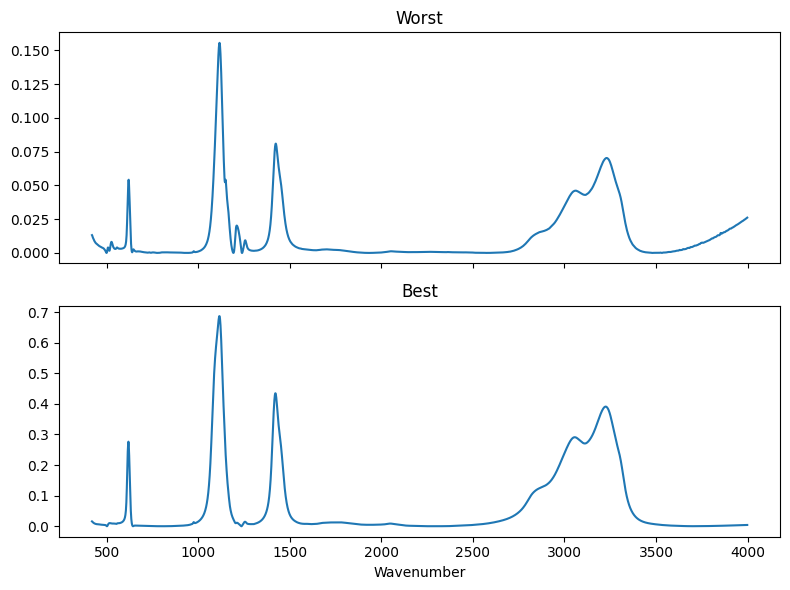

In [180]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

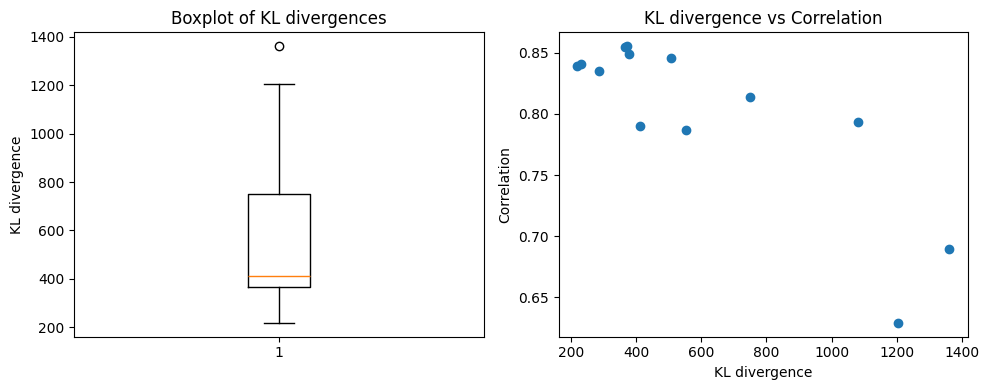

In [182]:
comp = "Malonic Acid"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

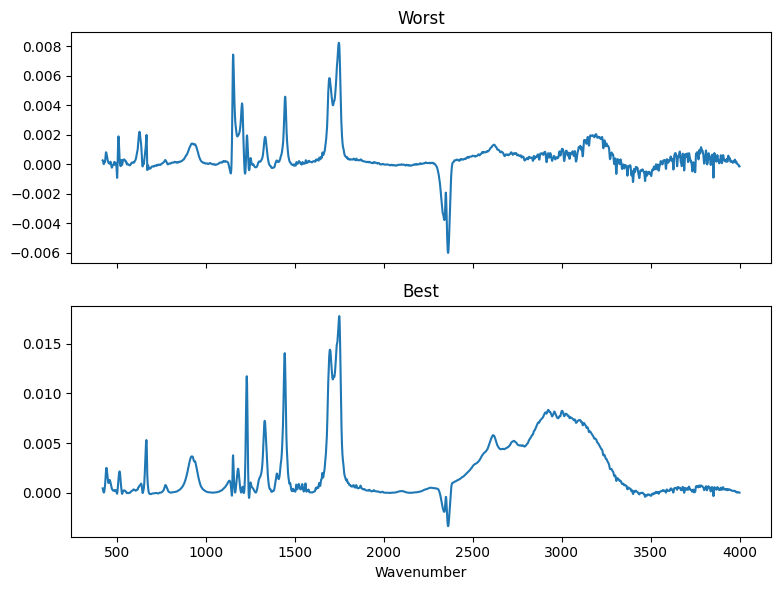

In [183]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

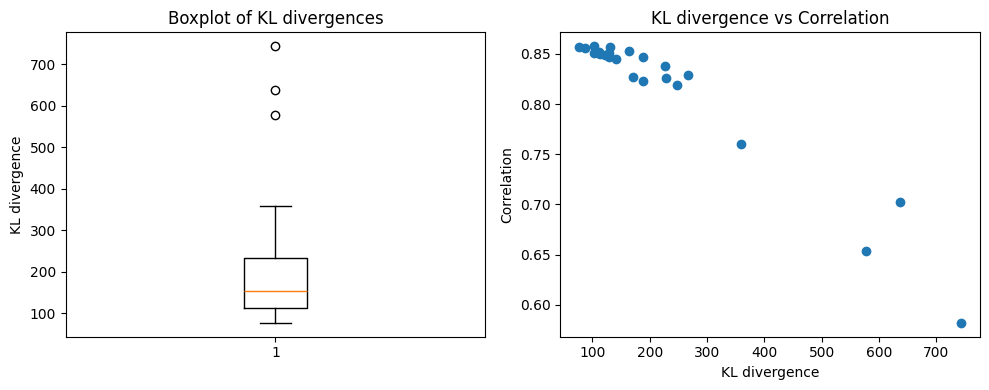

In [184]:
comp = "Suberic Acid"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

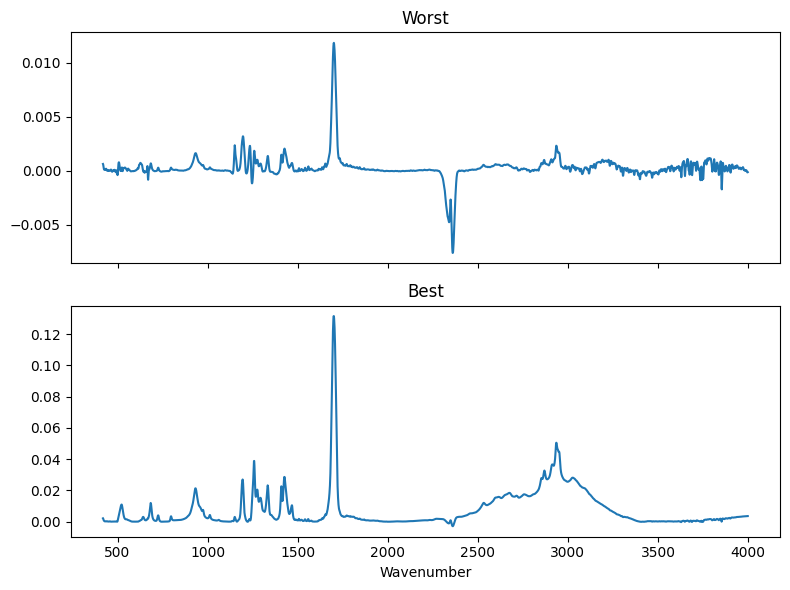

In [185]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

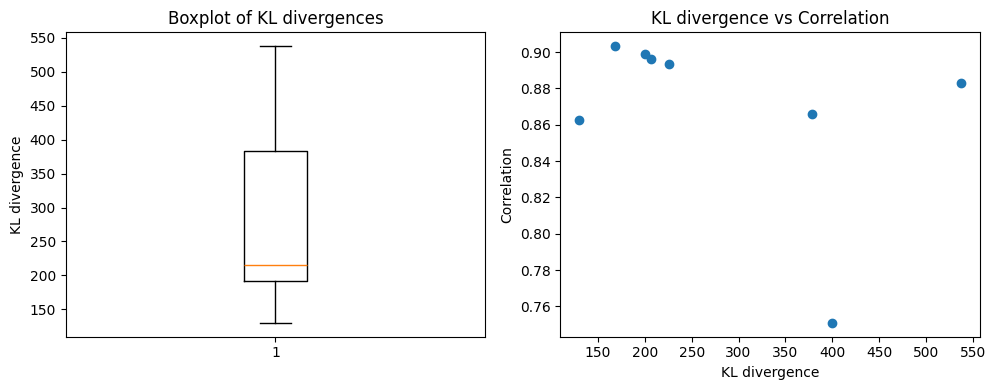

In [186]:
comp = "D-Glucose"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

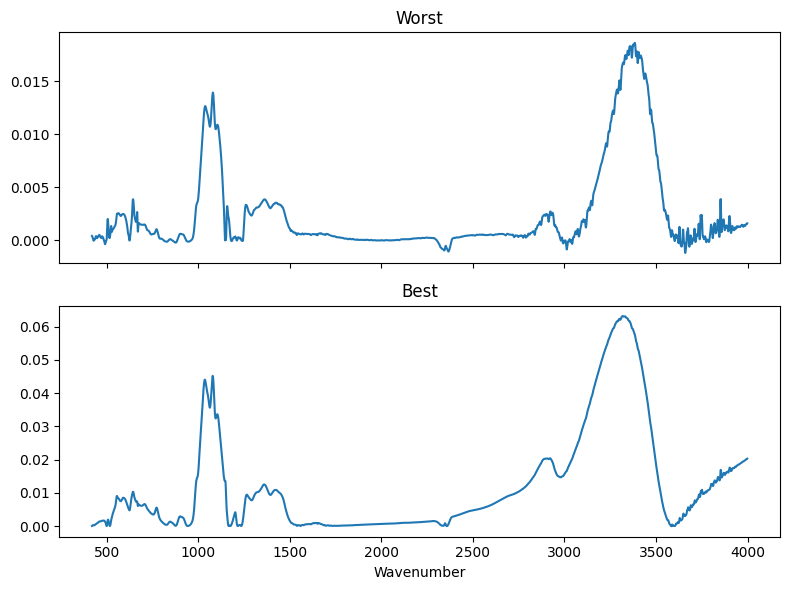

In [187]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

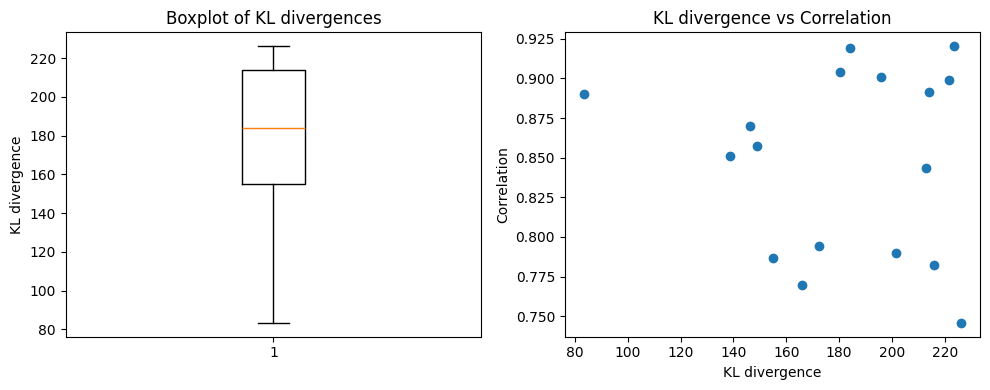

In [188]:
comp = "fructose"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

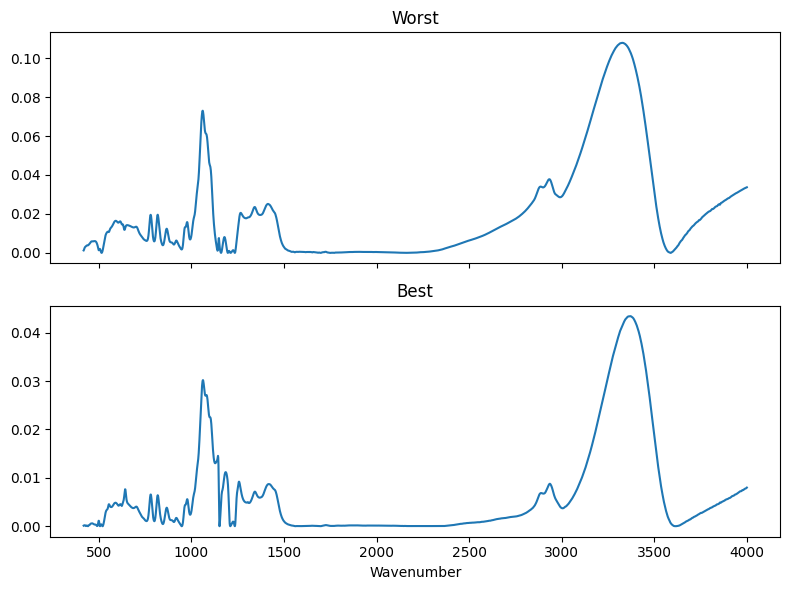

In [189]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()

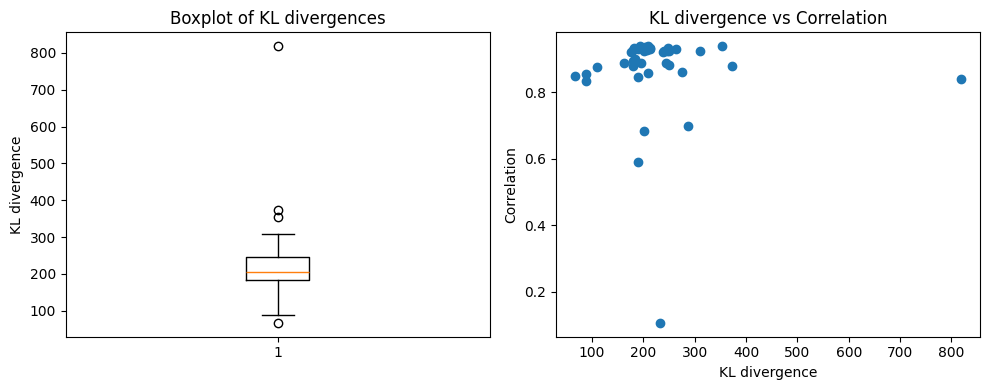

In [190]:
comp = "levoglucosan"

with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    corrections_dict = pickle.load(f)
corrections_dict = corrections_dict[comp]

cors = []
for k in range(len(corrections_dict)):
    estimated_abs = corrections_dict[k]["absorbance"]
    cors.append(np.corrcoef(np.interp(ref_dict[comp][:,0],wn, estimated_abs), ref_dict[comp][:,1])[0,1])
cors = np.array(cors)

nu = np.array([i["nu"] for i in corrections_dict])
d = np.array([i["d"] for i in corrections_dict])

KL = []
for i in range(nu.shape[0]):
    KL.append(np.sum(nu[i,:]**2 + d[i,:]**2 - 2*np.log(d[i,:]) - 1)/2)
KL = np.array(KL)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

# Left: boxplot
axes[0].boxplot(KL)
axes[0].set_title("Boxplot of KL divergences")
axes[0].set_ylabel("KL divergence")

# Right: scatter plot
axes[1].scatter(KL, cors)
axes[1].set_title("KL divergence vs Correlation")
axes[1].set_xlabel("KL divergence")
axes[1].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

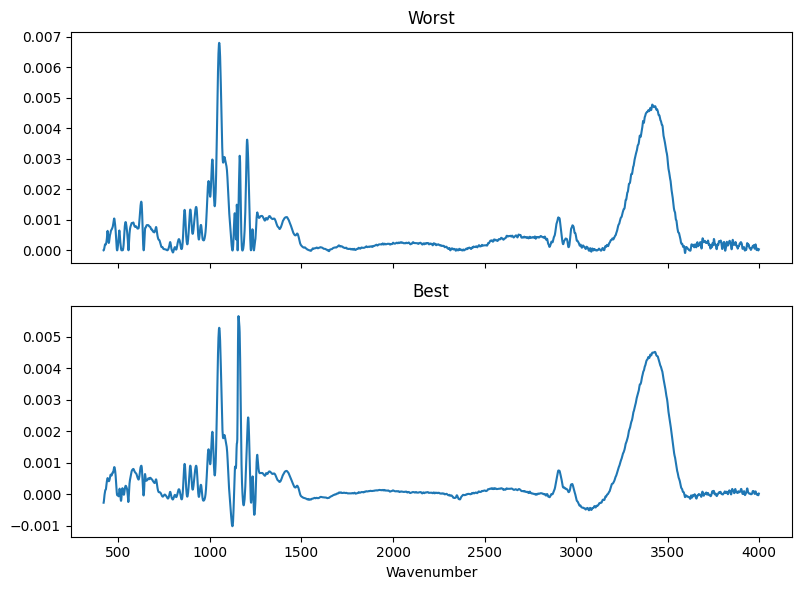

In [191]:
best = np.argsort(KL)[0]
worst = np.argsort(KL)[-1]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axes[0].plot(wn, corrections_dict[worst]["absorbance"])
axes[0].set_title("Worst")

axes[1].plot(wn, corrections_dict[best]["absorbance"])
axes[1].set_title("Best")

plt.xlabel("Wavenumber")
plt.tight_layout()
plt.show()